In [1]:
from pathlib import Path
import os

DATAPATH = Path("./ebola_data").resolve()
os.environ["DATAPATH"] = str(DATAPATH)
print(f"DATAPATH set to: {DATAPATH}")

DATAPATH set to: /home/dmoi/projects/ESM3di/ebola_data/ebola_data


In [ ]:
# loop over all fasta files in the data directory and run cd-hit to cluster sequences at 90% identity
run_cdhit = False
if run_cdhit == True:
	for fasta_file in DATAPATH.glob("*.fasta"):
		output_file = fasta_file.with_name(f"{fasta_file.stem}_cdhit.fasta")
		os.system(f"cd-hit -i {fasta_file} -o {output_file} -c 0.9 -n 5")

Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 22:00:32
Command: cd-hit -i
         /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_NP_cdhit_cdhit_cdhit_cdhit_cdhit_cdhit_cdhit.fasta
         -o
         /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_NP_cdhit_cdhit_cdhit_cdhit_cdhit_cdhit_cdhit_cdhit.fasta
         -c 0.9 -n 5

Started: Wed Jul 29 15:10:10 2026
                            Output                              
----------------------------------------------------------------
total seq: 66
longest and shortest : 749 and 608
Total letters: 48121
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 0M
Buffer          : 1 X 16M = 16M
Table           : 1 X 65M = 65M
Miscellaneous   : 0M
Total           : 81M

Table limit with the given memory limit:
Max number of representatives: 855532
Max number of word counting entries: 89804025

comparing sequences from          0  to         66

       66  finished         66  clusters

Ap


      108  finished        108  clusters

Approximated maximum memory consumption: 83M
writing new database
writing clustering information
program completed !

Total CPU time 2.90
Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 22:00:32
Command: cd-hit -i
         /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_NP.fasta
         -o
         /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_NP_cdhit.fasta
         -c 0.9 -n 5

Started: Wed Jul 29 15:10:15 2026
                            Output                              
----------------------------------------------------------------
total seq: 3461
longest and shortest : 749 and 588
Total letters: 2549283
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 2M
Buffer          : 1 X 16M = 16M
Table           : 1 X 65M = 65M
Miscellaneous   : 0M
Total           : 84M

Table limit with the given memory limit:
Max number of representatives: 851881
Max number of word counting entries: 89420

In [4]:
%%bash
set -euo pipefail

MODEL_CKPT="../checkpoints/esm3di_from_mlm/epoch_5.pt"
INPUT_DIR="$DATAPATH/"
OUTPUT_ROOT="$DATAPATH/ebola_protfams"

mkdir -p "$OUTPUT_ROOT"

find "$INPUT_DIR" -maxdepth 1 -type f \( -name "*.fa" -o -name "*.fasta" -o -name "*.faa" \) | while read -r aa_fasta; do
	fname="$(basename "$aa_fasta")"
	stem="${fname%.*}"
	out_dir="$OUTPUT_ROOT/$stem"
	mkdir -p "$out_dir"

	db_name="${stem}_foldseekdb"
	output_db="$out_dir/$db_name"

	python -m esm3di.fastas2foldseekdb \
		--aa-fasta "$aa_fasta" \
		--model-ckpt "$MODEL_CKPT" \
		--output-db "$output_db" \
		--num-gpus 1 \
		--revision 46c5f7d \
		--keep-fastas
done

Checking for FoldSeek installation...
✓ FoldSeek found

Running ESM inference on /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_GP.fasta...
Using model: ../checkpoints/esm3di_from_mlm/epoch_5.pt
Device: cuda
Loading model configuration from checkpoint...


Using model revision: 46c5f7d
Using single GPU: cuda
Initializing ESM3DiModel with Synthyra/ESMplusplus_small...

Loading model: Synthyra/ESMplusplus_small


Attention backend: config='sdpa' -> resolved='sdpa'


Loading weights: 100%|██████████| 308/308 [00:00<00:00, 2047.42it/s]
[transformers] ESMplusplusForTokenClassification LOAD REPORT from: Synthyra/ESMplusplus_small
Key                         | Status  | 
----------------------------+---------+-
classifier.{0, 2, 3}.weight | MISSING | 
classifier.{0, 2, 3}.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

...

Attention backend: config='sdpa' -> resolved='sdpa'


Loading weights: 100%|██████████| 308/308 [00:00<00:00, 2358.03it/s]
[transformers] ESMplusplusForTokenClassification LOAD REPORT from: Synthyra/ESMplusplus_small
Key                         | Status  | 
----------------------------+---------+-
classifier.{0, 2, 3}.weight | MISSING | 
classifier.{0, 2, 3}.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Processed 40/108 sequences
Processed 80/108 sequences
Processed 108/108 sequences
Writing predictions to: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb_3di.fasta
✓ Prediction complete! 108 sequences written to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb_3di.fasta
✓ FASTA files ready

Creating FoldSeek database: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb
Finished writing Foldseek database to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb
Total sequences: 108
Pep file: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb, size: 235927 bytes
TDI file: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb_ss, size: 235927 bytes
Header file: /home/dmoi/projects/ESM3

In [ ]:
#run 3di prediction on the clustered fasta files

In [5]:
import glob
#check if the output files exist
output_files = glob.glob(f"{DATAPATH}/ebola_protfams/*/*.index")
if len(output_files) == 0:
	raise FileNotFoundError("No output .index files were created. Please check the previous steps for errors.")

In [6]:
conda install -c bioconda foldtree

Channels:
 - bioconda
 - conda-forge
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /home/dmoi/miniforge3/envs/fastas2foldseekdb

  added / updated specs:
    - foldtree


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    charset-normalizer-3.4.9   |     pyhd8ed1ab_0          60 KB  conda-forge
    gitpython-3.1.57           |     pyhd8ed1ab_0         162 KB  conda-forge
    lerc-4.2.0                 |       hdb68285_0         265 KB  conda-forge
    libjpeg-turbo-3.2.0        |       hb03c661_0         638 KB  conda-forge
    pixman-0.46.4              |       h54a6638_2         367 KB  conda-forge
    python-fastjsonschema-2.22.1|     pyhcf101f3_0         246 KB  conda-forge
    python-tzdata-2026.3       |     pyhd8ed1ab_0         143 KB  conda-forge
    pytz-2026.3.post1          |     pyhcf101f3_0         196 KB  conda-forge
    smart_open-8

In [7]:
#create a foldtree for each family

import os
import glob
import subprocess

def runFoldseek_allvall( dbpath , outfolder , foldseekpath = 'foldseek' , maxseqs = 3000):
	'''
	run foldseek search and createtsv
	
	parameters
	----------
	dbpath : str
		path to foldseek database
	outfolder : str 
		path to output folder
	maxseqs : int   
		maximum number of sequences to compare to

	'''
	if not os.path.exists(outfolder):
		os.makedirs(outfolder)
	dbfolder = os.path.dirname(dbpath)

	cmd = foldseekpath + " easy-search " + dbpath + " "+ dbpath +" "+ outfolder+"/allvall.csv " +  dbfolder+"/tmp --format-output 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits' --exhaustive-search --alignment-type 2" 
	subprocess.run(cmd, shell=True, check=True)
	
	return outfolder +'aln_score.tsv'

protfam_folders = glob.glob(f"{DATAPATH}/ebola_protfams/*") + glob.glob(f"{DATAPATH}/ebola_protfams_cdhit/*")
for folder in protfam_folders:
	db_files = glob.glob(f"{folder}/*.index")
	if len(db_files) == 0:
		print(f"No .index files found in {folder}. Skipping.")
		continue

	db_path = db_files[0].replace('.index', '')  # Assuming there's only one .index file per folder
	db_path = db_path.replace('_h', '')  # Ensure the path uses forward slashes
	db_path = db_path.replace('_ss', '')  # Ensure the path uses forward slashes
	
	output_folder = os.path.join(folder, "foldseek_results")
	print(f"Running foldseek for {db_path}...")
	if not os.path.exists(os.path.join(output_folder, "allvall.csv")):  # Check if results already exist	
		runFoldseek_allvall(db_path, output_folder)
		print(f"Results saved in {output_folder}.")
	else:
		print(f"Results already exist in {output_folder}. Skipping foldseek run.")


Running foldseek for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/Ebola_NP_cdhit_foldseekdb...


Create directory /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/tmp
easy-search /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/Ebola_NP_cdhit_foldseekdb /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/Ebola_NP_cdhit_foldseekdb /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/foldseek_results/allvall.csv /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/tmp --format-output query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits --exhaustive-search --alignment-type 2 

MMseqs Version:                    	10.941cd33
Seq. id. threshold                 	0
Coverage threshold                 	0
Coverage mode                      	0
Max reject                         	2147483647
Max accept                         	2147483647
Add backtrace                      	false
TMscore threshold                  	0
TMscore thresho

In [8]:
import shlex
def runQuicktree(   clusterfile , quicktreepath= 'quicktree' ):
	'''
	run quicktree

	parameters
	----------
	clusterfile : str
		path to all vs all distance matrix in fastme format
	quicktreepath : str 
		path to quicktree binary

	'''
	args = quicktreepath + ' -i m ' + clusterfile +' > ' + clusterfile + '.struct_tree.nwk'
	print(args)
	p =subprocess.run(args , shell= True)
	return clusterfile + '.struct_tree.nwk'


def runFastme(   clusterfile , fastmepath= 'fastme' ):
	'''
	run fastme

	parameters
	----------
	clusterfile : str
		path to all vs all distance matrix in fastme format
	fastmepath : str 
		path to fastme binary

	'''
	args = fastmepath + ' -i ' + clusterfile +' -o ' + clusterfile + '.struct_tree.nwk'
	print(args)
	p =subprocess.run(args , shell= True)
	return clusterfile + '.struct_tree.nwk'


In [13]:
#finish up 
import sys
import os
import pandas as pd
import numpy as np
import tqdm
from matplotlib import pyplot as plt

run_trees= False


foldtree_dir = '/home/dmoi/projects/fold_tree'
fastmepath = 'fastme'
delta = 1e-5

sys.path.append(foldtree_dir)
import foldtree.foldseek2tree as ft1

if run_trees == True:
	for folder in protfam_folders:
		alnres = f"{folder}/foldseek_results/allvall.csv"
		res = pd.read_table(alnres , header = None )
		res[0] = res[0].map(lambda x :x.replace('.pdb', ''))
		res[1] = res[1].map(lambda x :x.replace('.pdb', ''))
		res.columns = 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits'.split(',')
		#drop rows where query and target are the same
		res = res[res['query'] != res['target']]
		
		res.fident.hist(bins = 100)
		plt.show()
		ids = list( set(list(res['query'].unique()) + list(res['target'].unique())))
		pos = { protid : i for i,protid in enumerate(ids)}
		kernels = ['fident']
		matrices = { k:np.zeros((len(pos), len(pos))) for k in kernels }
		print(res)

		#calc kernel for tm, aln score, lddt
		for idx,row in tqdm.tqdm(res.iterrows(), total=res.shape[0]):
			for k in matrices:
				matrices[k][pos[row['query']] , pos[row['target']]] += row[k]
				matrices[k][pos[row['target']] , pos[row['query']]] += row[k]

		trees = {}
		for i,k in enumerate(matrices):
			matrices[k] /= 2
			matrices[k] = 1-matrices[k]
			matrices[k][np.diag_indices_from(matrices[k])] = 0
			#floor at 0.0001 to avoid issues with fastme
			matrices[k][matrices[k] < delta] = delta
			

			if k == 'fident':
				distmat = ft1.Tajima_dist( matrices[k] , bfactor = .93 , iter = 100 )
			else:
				distmat = ft1.Tajima_dist( matrices[k] )
			print(distmat,  np.amax(distmat), np.amin(distmat) )

			#save the distance matrix and run fastme to the same folder as the input csv file
			np.save( os.path.join(folder, k + '_distmat.npy') , distmat)
			distmat_txt = ft1.distmat_to_txt( ids , distmat , os.path.join(folder, k + '_distmat.txt') )
			treefile = ft1.runQuicktree( clusterfile=distmat_txt )
			out_tree = ft1.postprocess(treefile, treefile+'.pp.nwk' , delta = delta)
			trees[k] = out_tree
			

In [14]:
import os
from typing import Dict, List, Optional

from Bio import Entrez

def _extract_tax_id_from_feature_table(feature_table: List[dict]) -> str:
    """Extract NCBI taxon ID from GenBank feature qualifiers."""
    for feature in feature_table or []:
        for qualifier in feature.get("GBFeature_quals", []) or []:
            if qualifier.get("GBQualifier_name") != "db_xref":
                continue
            value = qualifier.get("GBQualifier_value", "")
            if value.startswith("taxon:"):
                return value.split(":", 1)[1]
    return ""


def fetch_taxonomic_info(
    accessions: List[str],
    batch_size: int = 10,
    seq_type: str = "nucleotide",
    email: Optional[str] = None,
    api_key: Optional[str] = None,
) -> Dict[str, Dict]:
    """
    Fetch taxonomic information for a list of accessions using NCBI Entrez.
    
    Args:
        accessions: List of NCBI accession numbers
        batch_size: Number of accessions to fetch per batch (default: 10)
        seq_type: Type of sequence - "nucleotide" or "protein" (default: "nucleotide")
        email: Entrez contact email. Defaults to NCBI_EMAIL env var when omitted.
        api_key: NCBI API key. Defaults to NCBI_API_KEY env var when omitted.
        
    Returns:
        Dictionary with accession as key and taxonomic info as value
    """
    
    Entrez.email = email or os.environ.get("NCBI_EMAIL", "dmoi@unil.ch")
    Entrez.api_key = api_key or os.environ.get("NCBI_API_KEY")
    
    # Map sequence type to NCBI database
    db_map = {"nucleotide": "nucleotide", "protein": "protein"}
    db = db_map.get(seq_type.lower(), "nucleotide")
    
    taxonomic_info = {}
    
    # Process accessions in batches
    for i in tqdm.tqdm(range(0, len(accessions), batch_size)):
        batch = accessions[i:i + batch_size]
        
        try:
            # Accession identifiers belong to sequence DBs, not the taxonomy DB.
            accession_ids = ",".join(batch)
            handle = Entrez.efetch(db=db, id=accession_ids, rettype="gb", retmode="xml")
            records = Entrez.read(handle)
            handle.close()

            found = set()
            for record in records:
                acc_version = record.get("GBSeq_accession-version", "")
                primary = record.get("GBSeq_primary-accession", "")
                accession_key = acc_version or primary
                if not accession_key:
                    continue

                normalized_candidates = {accession_key, primary, accession_key.split(".")[0]}
                matched_accession = next((a for a in batch if a in normalized_candidates), accession_key)

                taxonomic_info[matched_accession] = {
                    "accession": accession_key,
                    "tax_id": _extract_tax_id_from_feature_table(record.get("GBSeq_feature-table", [])),
                    "organism": record.get("GBSeq_organism", ""),
                    "scientific_name": record.get("GBSeq_organism", ""),
                    "taxonomy": record.get("GBSeq_taxonomy", ""),
                    "lineage": record.get("GBSeq_taxonomy", ""),
                    "division": record.get("GBSeq_division", ""),
                }
                found.add(matched_accession)

            for accession in batch:
                if accession not in found and accession not in taxonomic_info:
                    taxonomic_info[accession] = {
                        "error": "No sequence record found for accession in requested DB",
                        "db": db,
                    }

        except Exception as e:
            for accession in batch:
                taxonomic_info[accession] = {"error": str(e)}
    
    return taxonomic_info


# Example usage:
if __name__ == "__main__":
    accessions = ["NC_001802", "NC_045512.2"]  # Example nucleotide accessions
    result = fetch_taxonomic_info(accessions, seq_type="nucleotide")

    for acc, info in result.items():
        print(f"Accession: {acc}")
        print(f"Organism: {info.get('organism')}")
        print(f"Taxonomy: {info.get('taxonomy')}")
        print(f"TaxID: {info.get('tax_id')}")
        print()


100%|██████████| 1/1 [00:00<00:00,  1.28it/s]

Accession: NC_001802
Organism: Human immunodeficiency virus 1
Taxonomy: Viruses; Riboviria; Pararnavirae; Artverviricota; Revtraviricetes; Ortervirales; Retroviridae; Orthoretrovirinae; Lentivirus; Lentivirus humimdef1
TaxID: 11676

Accession: NC_045512.2
Organism: Severe acute respiratory syndrome coronavirus 2
Taxonomy: Viruses; Riboviria; Orthornavirae; Pisuviricota; Pisoniviricetes; Nidovirales; Cornidovirineae; Coronaviridae; Orthocoronavirinae; Betacoronavirus; Sarbecovirus; Betacoronavirus pandemicum
TaxID: 2697049



In [15]:
#run find this for all accessions in the input fasta files and save the results to a csv file
import glob
for fasta in glob.glob(f"{DATAPATH}/*.fasta"):
	accessions = []
	with open(fasta, 'r') as f:
		for line in f:
			if line.startswith('>'):
				accession = line[1:].strip().split()[0]
				accessions.append(accession)

	taxonomic_info = fetch_taxonomic_info(accessions, seq_type="protein")

	output_csv = os.path.splitext(fasta)[0] + "_taxonomic_info.csv"
	df = pd.DataFrame.from_dict(taxonomic_info, orient='index')
	df.to_csv(output_csv)
	print(f"Taxonomic information saved to {output_csv}")

  0%|          | 0/295 [00:00<?, ?it/s]

  6%|▌         | 17/295 [00:14<04:03,  1.14it/s]


KeyboardInterrupt: 

In [22]:
#find all trees and save them to a new folder
import shutil
trees = glob.glob(f"{DATAPATH}/ebola_protfams/*/*.pp.nwk") + glob.glob(f"{DATAPATH}/ebola_protfams_cdhit/*/*.pp.nwk")
print(trees)
output_tree_folder = os.path.join(DATAPATH, "ebola_trees")
if not os.path.exists(output_tree_folder):
	os.makedirs(output_tree_folder)
#copy all trees to the new folder
for tree in trees:
	fam_nam = tree.split('/')[-2]
	tree_name = os.path.basename(tree)
	output_tree_path = os.path.join(output_tree_folder, f"{fam_nam}_{tree_name}")


	if not os.path.exists(output_tree_path):
		shutil.copy(tree, output_tree_path)
		print(f"Copied {tree} to {output_tree_path}")
	else:
		print(f"{output_tree_path} already exists. Skipping copy.")

['/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP_cdhit/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_NP_cdhit/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_GP_cdhit/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_L_cdhit/fident_distmat.txt.struct_tree.nwk.pp.nwk']
Copied /h

In [23]:
#load all taxdata csv files and merge them into a single dataframe
taxdata_files = glob.glob(f"{DATAPATH}/*_taxonomic_info.csv")
if not taxdata_files:
	print("No taxonomic info CSV files found. Please check the previous steps for errors.")
else:
	taxdata_dfs = [pd.read_csv(f) for f in taxdata_files]
	merged_taxdata_df = pd.concat(taxdata_dfs, ignore_index=True)
	print(f"Merged taxonomic information saved to {len(merged_taxdata_df)} records.")
	print(merged_taxdata_df.head())

Merged taxonomic information saved to 10095 records.
   Unnamed: 0   accession     tax_id                       organism  \
0  AAA42977.1  AAA42977.1   186538.0               Zaire ebolavirus   
1  AAA46563.1  AAA46563.1  3052505.0  Orthomarburgvirus marburgense   
2  BAB69003.1  BAB69003.1   129003.0     Reston ebolavirus - Reston   
3  AAU43883.1  AAU43883.1   186540.0               Sudan ebolavirus   
4  ACI28620.1  ACI28620.1   565995.0               Bundibugyo virus   

                 scientific_name  \
0               Zaire ebolavirus   
1  Orthomarburgvirus marburgense   
2     Reston ebolavirus - Reston   
3               Sudan ebolavirus   
4               Bundibugyo virus   

                                            taxonomy  \
0  Viruses; Riboviria; Orthornavirae; Negarnaviri...   
1  Viruses; Riboviria; Orthornavirae; Negarnaviri...   
2  Viruses; Riboviria; Orthornavirae; Negarnaviri...   
3  Viruses; Riboviria; Orthornavirae; Negarnaviri...   
4  Viruses; Riboviria; 

⚠️ toytree | draw_toytree:get_tree_style_updated_by_draw_args | Unrecognized arguments skipped: ['tip_labels_color', 'show_node_labels'].
Check the docs, argument names may have changed.
⚠️ toytree | draw_toytree:get_tree_style_updated_by_draw_args | Unrecognized arguments skipped: ['tip_labels_color', 'show_node_labels'].
Check the docs, argument names may have changed.


⚠️ toytree | draw_toytree:get_tree_style_updated_by_draw_args | Unrecognized arguments skipped: ['tip_labels_color', 'show_node_labels'].
Check the docs, argument names may have changed.
⚠️ toytree | draw_toytree:get_tree_style_updated_by_draw_args | Unrecognized arguments skipped: ['tip_labels_color', 'show_node_labels'].
Check the docs, argument names may have changed.
⚠️ toytree | draw_toytree:get_tree_style_updated_by_draw_args | Unrecognized arguments skipped: ['tip_labels_color', 'show_node_labels'].
Check the docs, argument names may have changed.
⚠️ toytree | draw_toytree:get_tree_style_updated_by_draw_args | Unrecognized arguments skipped: ['tip_labels_color', 'show_node_labels'].
Check the docs, argument names may have changed.
⚠️ toytree | draw_toytree:get_tree_style_updated_by_draw_args | Unrecognized arguments skipped: ['tip_labels_color', 'show_node_labels'].
Check the docs, argument names may have changed.


<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="800.0px" height="600.0px" viewBox="0 0 800.0 600.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t339cb11ae6fd4dbebe9b6d55827fa60c"> QNL27238.1 QNL24160.1 AAB81004.1 QNL24358.1 QNL24151.1 QNL27283.1 AND81215.1 AKC37129.1 QNL27814.1 QWX21645.1 QNL26320.1 QNL26302.1 QNL25078.1 QNL27796.1 QNL27166.1 QNL27256.1 AKI83423.1 QNL24502.1 AYP10371.1 AYP10398.1 QYR86252.1 AYP10373.1 QNL24988.1 CAA78117.1 XJQ59053.1 WBV79888.1 AVM87245.1 UCU83238.1 QGM12360.2 QGM12357.2 XJQ58955.1 AAC40459.1 AZL87826.1 AYA01128.1 XJQ58976.1 XJQ59011.1 UTU41908.1 WEY07202.1 WEY07184.1 AAC54882.1 WEY06230.1 AAB37093.1 AAC54885.1 ASJ82195.1 AYP10415.1 ACI28624.1 AKC36032.1 AKC36410.1 AKC35951.1 ALB07126.1 AKC35933.1 AMY60255.1 QYR86846.1 QYR85154.1 QNL27697.1 QNL28703.1 QYR85550.1 QYR86864.1 QUJ10628.1 QYR85352.1 QNL26707.1 QYR86216.1 QNL26815.1 QYR86630.1 QNL27733.1 QNL28434.1 QNL25447.1 QNL28317.1 AYP10405.1 AYP10418.1 AMY60345.1 ASV62203.1 ASV62254.1 QNL27823.1

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="800.0px" height="600.0px" viewBox="0 0 800.0 600.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t55d112fe0d53458aa62412d812c871e9"> QNL24499.1 QNL27811.1 QYR86843.1 QYR86528.1 AZL57167.1 QNL24652.1 AER23671.1 QNL28700.1 AAA46563.1 YP_010798906.1 AVM87232.1 QYR86114.1 QUJ10616.1 QYR85151.1 QNL26704.1 AYP10427.1 QYR86177.1 QNL27856.1 QNL26290.1 QNL24148.1 AMY60342.1 YP_003815423.1 ACI28620.1 AAU43883.1 BAB69003.1 ASJ82192.1 AKC36407.1 AMY60252.1 QNL27298.1 ALG01105.1 AKG65328.1 QNL26317.1 AAA42977.1 QYR86627.1 QNL24724.1 QYR85646.1 QNL28431.1 QYR86240.1 QYR86861.1 QNL27262.1 QNL28988.1 QNL25534.1 QNL26497.1 AYP10410.1 AYP10372.1 AYP10417.1 AYP10402.1 AYP10384.1 QNL26299.1 QNL25444.1 AZL57185.1 AKU75255.1 AKC35930.1 AND81212.1 QNL28314.1 QNL27730.1 QYR85547.1 QNL28296.1 QNL29042.1 QYR85439.1 ALB07123.1 QNL24355.1 QNL27793.1 QNL25075.1 QUJ10607.1 QNL24328.1

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="800.0px" height="600.0px" viewBox="0 0 800.0 600.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="tbe4ea8b5adc94e2685e1c6f6556be971"> QNL24732.1 QNL24156.1 QYR85159.1 QWX21695.1 QWX21650.1 QWX21722.1 QNL28304.1 WWV92540.1 QNL28735.1 QNL24165.1 QYR85447.1 AND81220.1 WWV92828.1 WWV93305.1 QWX21659.1 QNL26298.1 AAV48581.1 AAA79970.1 ASJ82200.1 ACI28627.1 QNC49664.1 QNC49574.1 ACI28636.1 QYR86032.1 APW30001.1 QNL26307.1 AJA04390.1 QNL24534.1 AYA82998.1 QYR85393.1 QYR86257.1 QNL25155.1 QNL27324.1 AZL57184.1 AZL57169.1 QNL27666.1 WWV92810.1 QNL27864.1 AYP10422.1 AYP10431.1 QNL27486.1 QNL27621.1 QNL26145.1 QNL27189.1 WWV92873.1 QNL25731.1 QNL25542.1 QYR86194.1 QYR86869.1 QYR85555.1 QYR86635.1 QYR86248.1 QYR86851.1 QYR86185.1 QNL28996.1 QNL28286.1 QUJ10596.1 QNL27171.1 QNL26856.1 QNL26253.1 AJZ74655.1 QYR86122.1 QNL28430.1 QNL24660.1 QNL26712.1 QNL24507.1 ASV62251.1 QNL27270.1 QNL24300.1 QNL24363.1 QNL27828.1 AYW17029.1 QNL27810.1 QNL27504.1 AJZ74690.1 WWV93062.1 QNL27630.1 WWV92657.1 WWV92747.1 WWV92756.1 WWV93233.1 QWX21767.1 AZL57232.1 QNL27306.1 QNL28519.1 QNL26325.1 QNL27738.1 QNL25083.1 QYR85654.1 ALP30070.1 QTZ17677.1 QYR86536.1 ALF04606.1 QNL27819.1 QNL28438.1 QNL28322.1 QNL25569.1 QNL26271.1 QNL25452.1 QNL25659.1 QNL24705.1 QNL25983.1 AJZ74542.1 AJZ74707.1 AJZ74681.1 AJZ74533.1 ALB07131.1 AMY60260.1

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="800.0px" height="600.0px" viewBox="0 0 800.0 600.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t584ca5e2b9fb4f968261e75df9db52e8"> </p

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="800.0px" height="600.0px" viewBox="0 0 800.0 600.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t1d650e7dd36c402683297edc73ff46f8"> <path

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="800.0px" height="600.0px" viewBox="0 0 800.0 600.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="tf9ab91083b7f448ba215b248c40b9b03"> </p

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="800.0px" height="600.0px" viewBox="0 0 800.0 600.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t0a244f6e05c4479eb5161bbc9e3f3a9e"> <path d="M 54.4 207.3 L 54.4 207.4 L 5

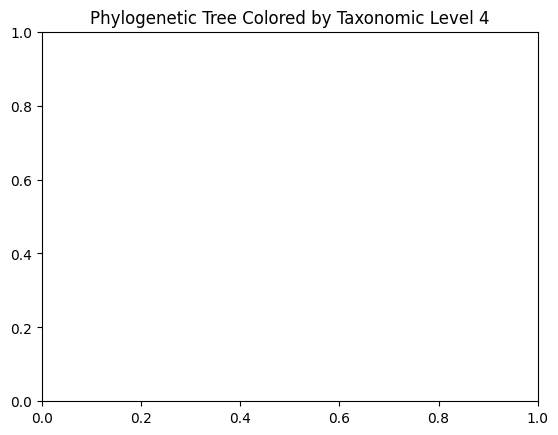

In [24]:
#load all trees and plot them using toytree
import toytree
import colour

tax_level = 4
ebola_tree_folder = os.path.join(DATAPATH, "ebola_trees")
for tree in glob.glob(f"{ebola_tree_folder}/*.pp.nwk"):
	tre = toytree.tree(tree)
	#find all rows in the merged taxdata_df that have the same tax_id and group them together
	subdf = merged_taxdata_df[merged_taxdata_df['tax_id'].isin(tre.get_tip_labels())]
	#select a taxonomic level to group by with a number
	subdf['levels'] = subdf['taxonomy'].map(lambda x: x.split(';'))
	subdf['tiplabel'] = subdf['levels'].map(lambda x: x[tax_level] if len(x) > tax_level else None)
	#choose a color for each tiplabel
	tiplabel_colors = {label: colour.Color(hue=i/len(subdf['tiplabel'].unique())) for i, label in enumerate(subdf['tiplabel'].unique())}
	#turn the color objects into long hex strings
	tiplabel_colors = {label: color.hex_l for label, color in tiplabel_colors.items()}
	#display the tree with the tiplabels colored by their taxonomic level
	tre.draw(tip_labels=True, tip_labels_color=[tiplabel_colors.get(label, '#000000') for label in tre.get_tip_labels()], node_sizes=5, node_colors='black', edge_colors='black', width=800, height=600, show_node_labels=False)
	plt.title(f"Phylogenetic Tree Colored by Taxonomic Level {tax_level}")

#choose a tax level


In [25]:
conda install -c bioconda emboss

Channels:
 - bioconda
 - conda-forge
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /home/dmoi/miniforge3/envs/fastas2foldseekdb

  added / updated specs:
    - emboss


The following NEW packages will be INSTALLED:

  emboss             bioconda/linux-64::emboss-6.6.0-h0f19ade_14 
  libgd              conda-forge/linux-64::libgd-2.3.3-h6f5c62b_11 
  libharu            conda-forge/linux-64::libharu-2.4.5-h943b412_0 




Preparing transaction: done
Verifying transaction: done
Executing transaction: done
WARNING conda.conda_pypi.main:notify_externally_managed_future(156): 
  Did you know? You can install many PyPI packages with conda
  using the conda-pypi beta. Get started:
    https://docs.conda.io/projects/conda/en/stable/new-features.html


Note: you may need to restart the kernel to use updated packages.


In [26]:
#function to run emboos sixpack to get the 6-frame translation of the nucleotide sequences
import subprocess
import os


def run_sixpack(nucleotide_fasta, output_folder):
	"""
	Run EMBOSS sixpack to get the 6-frame translation of the nucleotide sequences.

	Parameters:
	nucleotide_fasta (str): Path to the nucleotide FASTA file.
	output_folder (str): Path to the output folder where results will be saved.
	"""
	if not os.path.exists(output_folder):
		os.makedirs(output_folder)

	output_file = os.path.join(output_folder, "sixpack_output.fasta")
	cmd = f"sixpack -sequence {nucleotide_fasta} -outseq {output_file} -auto"
	
	subprocess.run(cmd, shell=True, check=True)
	
	return output_file

In [27]:
#use sixpack on the unknown ebola proteome
nucleotide_fasta = f"{DATAPATH}/../oberland_virus_geno.fasta"
output_folder = f"{DATAPATH}/sixpack_results"
sixpack_output = run_sixpack(nucleotide_fasta, output_folder)

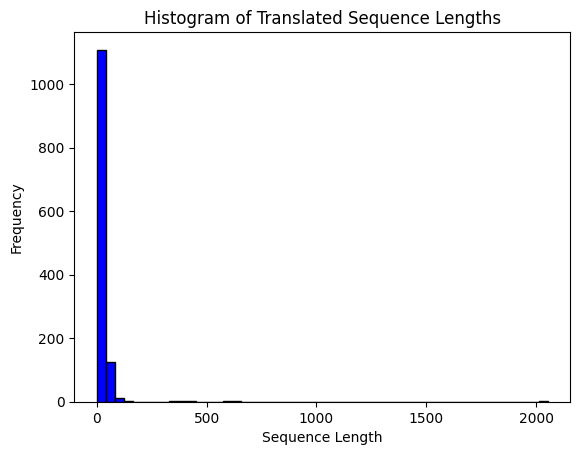

Number of sequences longer than 100 amino acids: 11


In [28]:
#create a histogram of the lengths of the translated sequences
import matplotlib.pyplot as plt

with open(sixpack_output, 'r') as f:
    sequences = []
    current_seq = ""
    for line in f:
        if line.startswith('>'):
            if current_seq:
                sequences.append(current_seq)
                current_seq = ""
        else:
            current_seq += line.strip()
    if current_seq:
        sequences.append(current_seq)

# Calculate the lengths of the sequences
sequence_lengths = [len(seq) for seq in sequences]

# Plot the histogram
plt.hist(sequence_lengths, bins=50, color='blue', edgecolor='black')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.title('Histogram of Translated Sequence Lengths')
plt.show()

#how many sequences are longer than 100 amino acids
long_sequences = [seq for seq in sequences if len(seq) > 100]
print(f"Number of sequences longer than 100 amino acids: {len(long_sequences)}")

In [29]:
#put the longer sequences into a new fasta file
long_sequences_fasta = os.path.join(output_folder, "oberland_long_sequences.fasta")
with open(long_sequences_fasta, 'w') as f:
    for i, seq in enumerate(long_sequences):
        f.write(f">long_seq_{i}\n")
        f.write(f"{seq}\n")

In [30]:
#set long_sequences_fasta and output_db for the next step

long_sequences_fasta = os.path.join(output_folder, "oberland_long_sequences.fasta")
output_db = f"{DATAPATH}/ebola_protfams/oberland_long_sequences/oberland_long_sequences_foldseekdb"
os.environ["long_sequences_fasta"] = long_sequences_fasta



In [32]:
%%bash


MODEL_CKPT="../checkpoints/esm3di_from_mlm/epoch_5.pt"
OUTPUT_ROOT="$DATAPATH/ebola_oberland"

fname="$(basename "$long_sequences_fasta")"
stem="${fname%.*}"
out_dir="$OUTPUT_ROOT/$stem"
mkdir -p "$out_dir"

db_name="${stem}_foldseekdb"
output_db="$out_dir/$db_name"
echo "Running foldseek database creation for $long_sequences_fasta..."


python -m esm3di.fastas2foldseekdb \
    --aa-fasta "$long_sequences_fasta" \
    --model-ckpt "$MODEL_CKPT" \
    --output-db "$output_db" \
	--revision 46c5f7d \
    --keep-fastas

Running foldseek database creation for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/sixpack_results/oberland_long_sequences.fasta...


Checking for FoldSeek installation...
✓ FoldSeek found

Running ESM inference on /home/dmoi/projects/ESM3di/ebola_data/ebola_data/sixpack_results/oberland_long_sequences.fasta...
Using model: ../checkpoints/esm3di_from_mlm/epoch_5.pt
Device: cuda
Loading model configuration from checkpoint...
Using model revision: 46c5f7d
Using 2 GPU(s) for inference on 11 sequences


Multi-GPU inference:   0%|          | 0/2 [00:07<?, ?GPU/s]


Falling back to single-GPU inference...
Using single GPU: cuda
Initializing ESM3DiModel with Synthyra/ESMplusplus_small...

Loading model: Synthyra/ESMplusplus_small


Attention backend: config='sdpa' -> resolved='sdpa'


Loading weights: 100%|██████████| 308/308 [00:00<00:00, 2074.70it/s]
[transformers] ESMplusplusForTokenClassification LOAD REPORT from: Synthyra/ESMplusplus_small
Key                         | Status  | 
----------------------------+---------+-
classifier.{0, 2, 3}.weight | MISSING | 
classifier.{0, 2, 3}.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Processed 11/11 sequences
Writing predictions to: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb_3di.fasta
✓ Prediction complete! 11 sequences written to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb_3di.fasta
✓ FASTA files ready

Creating FoldSeek database: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb
Finished writing Foldseek database to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb
Total sequences: 11
Pep file: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb, size: 5072 bytes
TDI file: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb_

In [33]:
#search against the foldseek databases we made to annotate the unknown ebola proteome
import glob

def run_foldseek( querydb, targetdb, output_folder, foldseekpath = 'foldseek' , maxseqs = 3000):
	'''
	run foldseek search and createtsv
	
	parameters
	----------
	querydb : str
		path to foldseek query database
	targetdb : str 
		path to foldseek target database
	output_folder : str 
		path to output folder
	maxseqs : int   
		maximum number of sequences to compare to

	'''
	if not os.path.exists(output_folder):
		os.makedirs(output_folder)
	

	target_name = os.path.basename(targetdb)
	cmd = f"{foldseekpath} easy-search {querydb} {targetdb} {output_folder}/{target_name}_search.csv tmp --format-output 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits' " 
	subprocess.run(cmd, shell=True, check=True)
	return os.path.join(output_folder, f"{target_name}_search.csv")

querydb = '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb'

protfam_folders = glob.glob(f"{DATAPATH}/ebola_protfams/*")
for folder in protfam_folders:
	db_files = glob.glob(f"{folder}/*.index")
	if len(db_files) == 0:
		print(f"No .index files found in {folder}. Skipping.")
		continue

	db_path = db_files[0].replace('.index', '')  # Assuming there's only one .index file per folder
	db_path = db_path.replace('_h', '')  # Ensure the path uses forward slashes
	output_folder = os.path.join(folder, "foldseek_search_results_oberland")
	print(f"Running foldseek search for {db_path}...")
	run_foldseek(querydb=querydb, targetdb=db_path, output_folder=output_folder)
	print(f"Search results saved in {output_folder}.")
    

Running foldseek search for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/Ebola_NP_cdhit_foldseekdb_ss...
easy-search /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/Ebola_NP_cdhit_foldseekdb_ss /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/foldseek_search_results_oberland/Ebola_NP_cdhit_foldseekdb_ss_search.csv tmp --format-output query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits 

MMseqs Version:                    	10.941cd33
Seq. id. threshold                 	0
Coverage threshold                 	0
Coverage mode                      	0
Max reject                         	2147483647
Max accept                         	2147483647
Add backtrace                      	false
TMscore threshold                  	0
TMscore threshold mode       

Input /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/Ebola_NP_cdhit_foldseekdb_ss_ss does not exist


CalledProcessError: Command 'foldseek easy-search /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/Ebola_NP_cdhit_foldseekdb_ss /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/foldseek_search_results_oberland/Ebola_NP_cdhit_foldseekdb_ss_search.csv tmp --format-output 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits' ' returned non-zero exit status 1.

In [34]:
#read off all of the results and make a summary table of the best hits for each query sequence
rescolumns = 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits'.split(',')
resfiles = glob.glob(f"{DATAPATH}/ebola_protfams/*/foldseek_search_results_oberland/*.csv")
import pandas as pd

all_results = []
for resfile in resfiles:
    df = pd.read_table(resfile, names=rescolumns, header=None)
    df['source_db'] = os.path.basename(resfile).replace('_search.csv', '')
    all_results.append(df)
all_results_df = pd.concat(all_results, ignore_index=True )
print(f"Total number of hits: {len(all_results_df)}")


Total number of hits: 8026


In [35]:
all_results_df
#drop evalues greater than 1e-5 and keep the best hit for each query sequence
all_results_df = all_results_df[all_results_df['evalue'] < 1e-5]
#get top 10 for each query sequence
best_hits_df = all_results_df.sort_values('evalue').groupby('query').head(10).reset_index(drop=True)
print(f"Number of best hits after filtering: {len(best_hits_df)}")

Number of best hits after filtering: 22


In [36]:
print("Best hits summary:")
print(best_hits_df)

Best hits summary:
         query          target  fident  alnlen  mismatch  gapopen  qstart  \
0   long_seq_5      QGM12360.2   1.000     618         0        0       5   
1   long_seq_5      QGM12360.2   1.000     618         0        0       5   
2   long_seq_5  YP_010800198.1   1.000     618         0        0       5   
3   long_seq_7      AGB56682.1   0.202    2063      1613        0      31   
4   long_seq_7      AAA79970.1   0.200    2063      1617        0      31   
5   long_seq_7      AAA79970.1   0.200    2063      1617        0      31   
6   long_seq_7      WEY07143.1   0.199    2063      1619        0      31   
7   long_seq_7      AGL50931.1   0.197    2063      1623        0      31   
8   long_seq_7      AGL50931.1   0.197    2063      1623        0      31   
9   long_seq_7      ACR33194.1   0.200    2063      1617        0      31   
10  long_seq_7      ACR33194.1   0.200    2063      1617        0      31   
11  long_seq_7      WEY06666.1   0.201    2073      1611 

In [37]:
outdir = f"{DATAPATH}/oberland_results"
if not os.path.exists(outdir):
    os.makedirs(outdir)
output_file = f"{DATAPATH}/oberland_results/best_hits_summary.csv"
best_hits_df.to_csv(output_file, index=False)
print(f"Best hits summary saved to {output_file}")

Best hits summary saved to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/oberland_results/best_hits_summary.csv


In [38]:
#add the long sequences to the original ebola proteome fasta files and save as a new fasta file. we should add each sequence to its appropriate family fasta file if it has a hit, otherwise we can put it in a separate fasta file for unknown sequences. we can use the best_hits_df to determine which family each long sequence belongs to.

for fam in best_hits_df['source_db'].unique():
	fam_df = best_hits_df[best_hits_df['source_db'] == fam]
	fam_fasta_file = f"{DATAPATH}/ebola_protfams/{fam}/{fam}.fasta"
	if not os.path.exists(fam_fasta_file):
		print(f"Family fasta file {fam_fasta_file} does not exist. Skipping.")
		continue

	# Read the original family fasta
	with open(fam_fasta_file, 'r') as f:
		original_fasta = f.read()

	# Append the long sequences that belong to this family
	with open(f"{DATAPATH}/oberland_results/{fam}_augmented.fasta", 'w') as f:
		f.write(original_fasta)
		for query in fam_df['query']:
			seq_id = query.split('|')[0]  # Assuming the query format is like ">long_seq_0|..."
			seq = next((s for s in long_sequences if s.startswith(seq_id)), None)
			if seq:
				f.write(f">{seq_id}\n{seq}\n")

Family fasta file /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP_foldseekdb/Ebola_GP_foldseekdb.fasta does not exist. Skipping.
Family fasta file /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L_foldseekdb/Ebola_L_foldseekdb.fasta does not exist. Skipping.
Family fasta file /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_foldseekdb/Ebola_NP_foldseekdb.fasta does not exist. Skipping.


In [ ]:
#let's add these long sequences to the original ebola proteome fasta files and save as a new fasta file. we should add each sequence to its appropriate family fasta file if it has a hit, otherwise we can put it in a separate fasta file for unknown sequences. we can use the best_hits_df to determine which family each long sequence belongs to.
